C:\Users\ahmad\AppData\Local\Temp\ipykernel_10676\2685400637.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Human_development', y='Maternal_mortality', data=std_data,
C:\Users\ahmad\AppData\Local\Temp\ipykernel_10676\2685400637.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='Seats_parliament', data=df_filtered,
C:\Users\ahmad\AppData\Local\Temp\ipykernel_10676\2685400637.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Kategori_GII', data=df_4, order=['Rendah', 'Sedang', 'Tinggi'],


Proses selesai. File 'Soal_5_Gabungan_Semua_Grafik.png' berhasil disimpan.


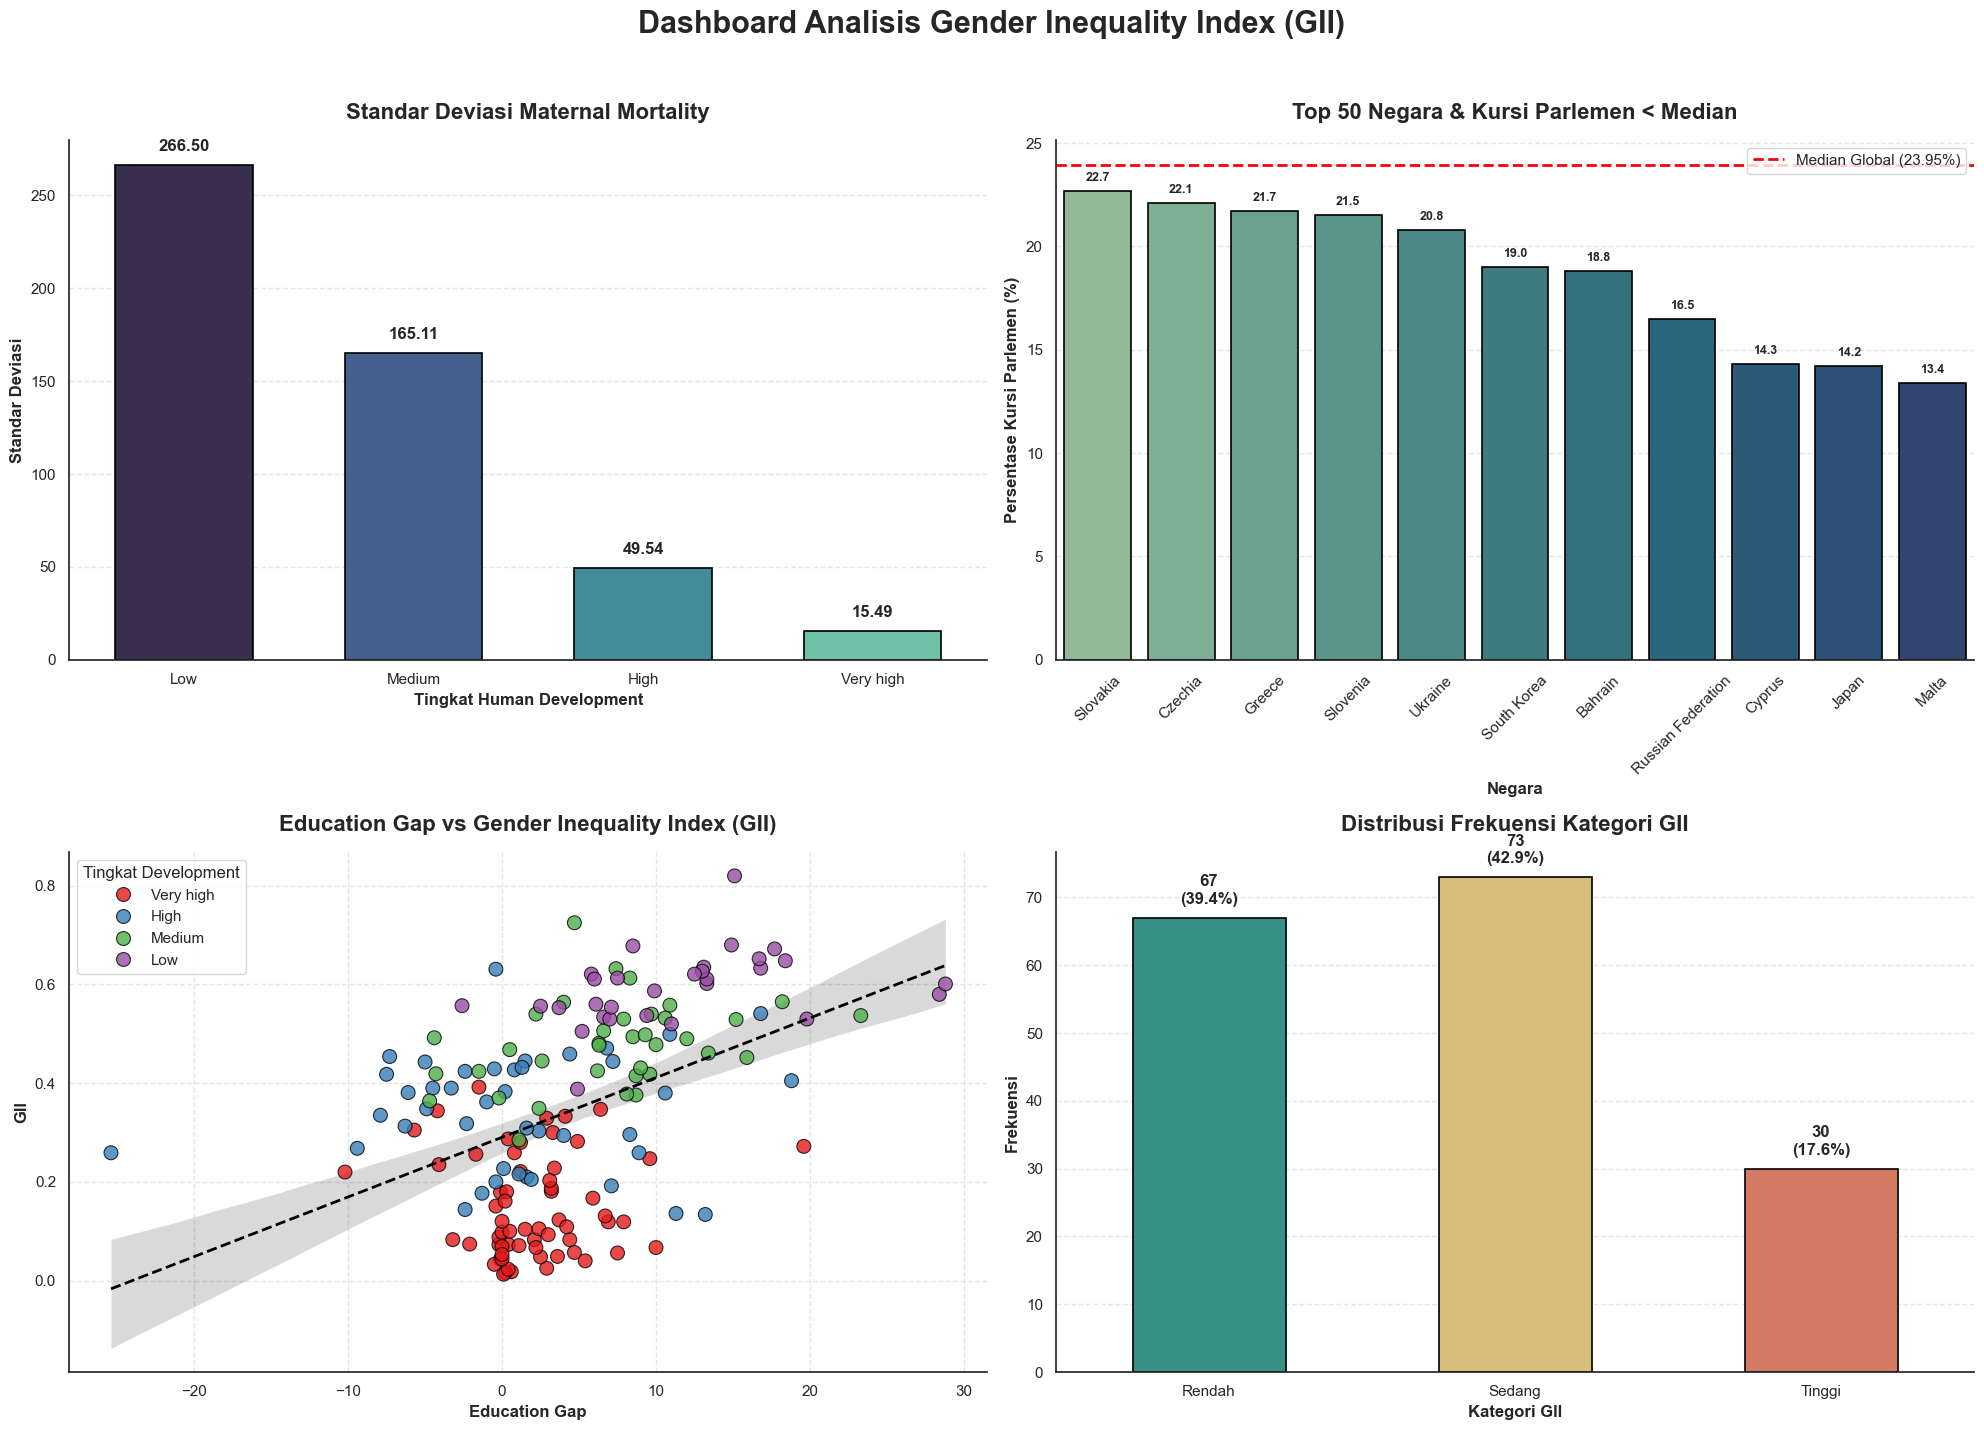

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. KONFIGURASI FIGUR UTAMA (GRID 2x2)
sns.set_theme(style="white", rc={"axes.facecolor": "#ffffff"})
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Menambahkan judul utama dashboard
fig.suptitle('Dashboard Analisis Gender Inequality Index (GII)', fontsize=22, fontweight='bold', y=1.02)

# 2. MEMBACA DATASET
df = pd.read_csv('Kelas A_Gender Inequality Index.csv')

# =====================================================================
# GRAFIK 1: KIRI ATAS (axes[0, 0]) - Standar Deviasi Maternal Mortality
# =====================================================================
# Pembersihan dan agregasi data
df_1 = df.dropna(subset=['Human_development', 'Maternal_mortality'])
std_data = df_1.groupby('Human_development')['Maternal_mortality'].std().reset_index()
std_data = std_data.sort_values('Maternal_mortality', ascending=False)

# Pembuatan visualisasi
sns.barplot(x='Human_development', y='Maternal_mortality', data=std_data, 
            palette='mako', edgecolor='black', linewidth=1.2, width=0.6, ax=axes[0, 0])

# Kustomisasi label dan anotasi
axes[0, 0].set_title('Standar Deviasi Maternal Mortality', fontsize=16, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('Tingkat Human Development', fontweight='bold')
axes[0, 0].set_ylabel('Standar Deviasi', fontweight='bold')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# =====================================================================
# GRAFIK 2: KANAN ATAS (axes[0, 1]) - Top 50 Rank & Kursi Parlemen
# =====================================================================
# Pembersihan data dan filter kondisi
df_2 = df.dropna(subset=['Country', 'Rank', 'Seats_parliament'])
median_global = df_2['Seats_parliament'].median()
df_filtered = df_2[(df_2['Rank'] <= 50) & (df_2['Seats_parliament'] < median_global)].copy()
df_filtered = df_filtered.sort_values(by='Seats_parliament', ascending=False)

# Pembuatan visualisasi
sns.barplot(x='Country', y='Seats_parliament', data=df_filtered, 
            palette='crest', edgecolor='black', linewidth=1.2, ax=axes[0, 1])

# Penambahan garis median dan kustomisasi
axes[0, 1].axhline(median_global, color='red', linestyle='--', linewidth=2, label=f'Median Global ({median_global:.2f}%)')
axes[0, 1].legend(loc='upper right')
axes[0, 1].set_title('Top 50 Negara & Kursi Parlemen < Median', fontsize=16, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('Negara', fontweight='bold')
axes[0, 1].set_ylabel('Persentase Kursi Parlemen (%)', fontweight='bold')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)
axes[0, 1].tick_params(axis='x', labelrotation=45)

for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# =====================================================================
# GRAFIK 3: KIRI BAWAH (axes[1, 0]) - Scatter Plot Education Gap vs GII
# =====================================================================
# Pembersihan data dan perhitungan selisih edukasi
df_3 = df.dropna(subset=['M_secondary_educ', 'F_secondary_educ', 'GII', 'Human_development']).copy()
df_3['Educ_Gap'] = df_3['M_secondary_educ'] - df_3['F_secondary_educ']

# Pembuatan visualisasi regresi dan scatter plot
sns.regplot(x='Educ_Gap', y='GII', data=df_3, scatter=False, color='black', 
            line_kws={'linestyle':'--', 'linewidth': 2}, ax=axes[1, 0])
sns.scatterplot(x='Educ_Gap', y='GII', hue='Human_development', palette='Set1', 
                data=df_3, s=100, alpha=0.8, edgecolor='black', ax=axes[1, 0])

# Kustomisasi
axes[1, 0].set_title('Education Gap vs Gender Inequality Index (GII)', fontsize=16, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('Education Gap', fontweight='bold')
axes[1, 0].set_ylabel('GII', fontweight='bold')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)
axes[1, 0].legend(title='Tingkat Development', loc='upper left')

# =====================================================================
# GRAFIK 4: KANAN BAWAH (axes[1, 1]) - Frekuensi Kategori GII
# =====================================================================
# Pembersihan data dan kategorisasi
df_4 = df.dropna(subset=['GII']).copy()
df_4['Kategori_GII'] = pd.cut(df_4['GII'], bins=3, labels=['Rendah', 'Sedang', 'Tinggi'])
total_data = len(df_4)

# Pembuatan visualisasi
sns.countplot(x='Kategori_GII', data=df_4, order=['Rendah', 'Sedang', 'Tinggi'], 
              palette=['#2a9d8f', '#e9c46a', '#e76f51'], edgecolor='black', linewidth=1.2, width=0.5, ax=axes[1, 1])

# Kustomisasi dan anotasi
axes[1, 1].set_title('Distribusi Frekuensi Kategori GII', fontsize=16, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('Kategori GII', fontweight='bold')
axes[1, 1].set_ylabel('Frekuensi', fontweight='bold')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[1, 1].patches:
    height = p.get_height()
    percentage = f'{(height/total_data)*100:.1f}%'
    axes[1, 1].annotate(f'{int(height)}\n({percentage})', (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# =====================================================================
# FINALISASI & PENYIMPANAN
# =====================================================================
sns.despine()
plt.tight_layout()

# Menyimpan hasil ke format PNG
plt.savefig('Soal_5_Gabungan_Semua_Grafik.png', dpi=300, bbox_inches='tight')

print("Proses selesai. File 'Soal_5_Gabungan_Semua_Grafik.png' berhasil disimpan.")